In [1]:
# =============================================================================
# CELDA 1: CARGA DE DATOS Y SANITY CHECK
# =============================================================================
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter('ignore')

# 1. Configuración de Estilo HEP
hep_style = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
    'axes.linewidth': 1.2,
    'legend.frameon': True, 'legend.shadow': True, 'legend.edgecolor': 'black',
    'lines.linewidth': 2, 'lines.markersize': 8
}
plt.rcParams.update(hep_style)

# Diccionario de colores (Agregalo si no lo tenías definido)
COLORS = {'Proton': 'royalblue', 'Iron': 'firebrick'}

# 2. Funciones Auxiliares
def ang_diff(a, b):
    """Diferencia angular más corta en el rango [-180, 180]"""
    d = a - b
    return (d + 180) % 360 - 180

def ensure_degrees(series):
    """Pasa radianes a grados si es necesario"""
    if series.dropna().abs().max() < 7.0: 
        return np.rad2deg(series)
    return series

def add_physics_annotations(ax):
    """Inyecta los metadatos de la simulación en el gráfico"""
    ax.text(0.95, 0.95, r"$\mathbf{Proton\ showers}$", transform=ax.transAxes, 
            fontsize=12, va='top', ha='right', color=COLORS['Proton'])
    ax.text(0.95, 0.88, r"$\mathbf{SIB2.3e}$", transform=ax.transAxes, 
            fontsize=12, va='top', ha='right', color='purple')
    ax.text(0.95, 0.81, r"$\log_{10}(E_0/\mathrm{eV}) = 17.5 - 18.0$", transform=ax.transAxes, 
            fontsize=11, va='top', ha='right')

folder_path = "/home/lsilva/Github/ADST_Alexey_module_v11/parquet_sib_proton_17/" 

print("Cargando archivos Parquet...")
all_dfs = []
parquets = glob.glob(os.path.join(folder_path, "*.parquet"))
        
for f in parquets:
    try:
        df = pd.read_parquet(f)
        all_dfs.append(df)
    except Exception as e:
        print(f"Error cargando {f}: {e}")

if len(all_dfs) > 0:
    df_guia = pd.concat(all_dfs, ignore_index=True)
    df_infill = df_guia[df_guia['counterId'] >= 100000].copy()
    print(f"Datos cargados exitosamente. Módulos Infill: {len(df_infill):,}")
else:
    print("No se cargaron datos.")
    df_infill = pd.DataFrame()

Cargando archivos Parquet...
Datos cargados exitosamente. Módulos Infill: 734,139


Generando Money Plots con Metadatos...


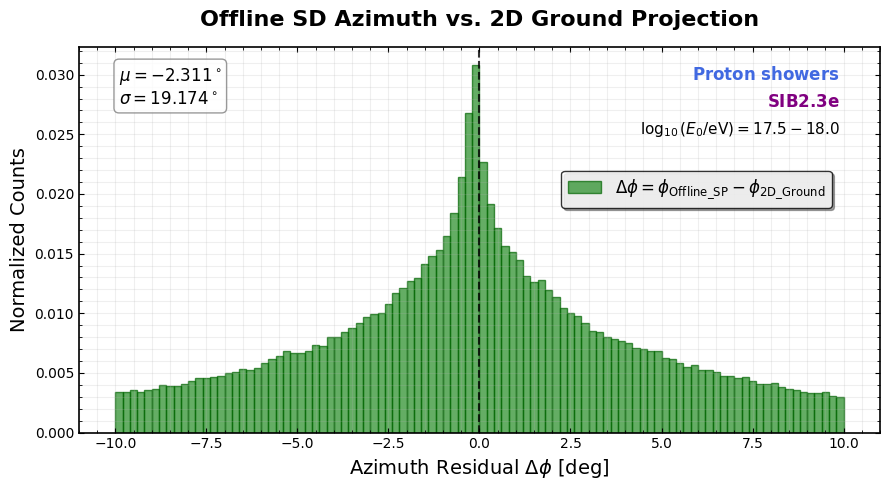

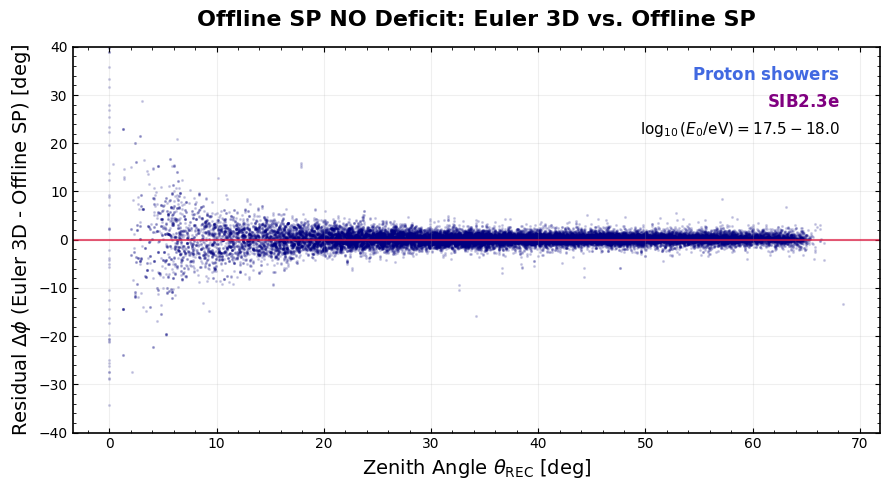

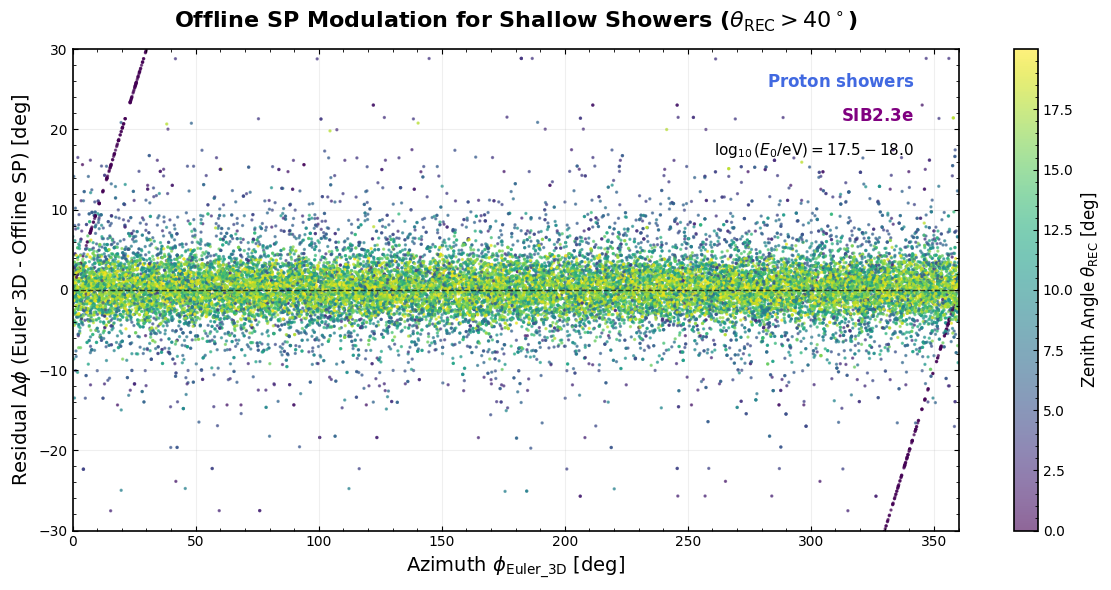

In [2]:
# --- 3. PROCESAMIENTO DE DATOS ---
if len(df_infill) > 0:
    print("Generando Money Plots con Metadatos...")
    
    # Extracción
    vals_sp = ensure_degrees(df_infill['phi_plane_sp'])
    vals_ground = ensure_degrees(df_infill['phi_plane_ground'])
    vals_euler = ensure_degrees(df_infill['phi_plane_euler_MC'])
    vals_rec_phi = ensure_degrees(df_infill['phi_REC'])
    vals_theta_rec = ensure_degrees(df_infill['theta_REC'])

    # Tratamiento de coordenadas (Llevar todo al mismo plano absoluto)
    vals_sp_fixed = (vals_sp + vals_rec_phi) % 360     # Restauramos el SP original
    vals_euler_fixed = (vals_euler - 180) % 360        # Removemos el offset +180
    
    # Cálculos de diferencias
    diff_offline_ground = ang_diff(vals_sp_fixed, vals_ground)
    diff_euler_sp = ang_diff(vals_euler_fixed, vals_sp_fixed)

    # -------------------------------------------------------------------------
    # PLOT 1: HISTOGRAMA DE RESIDUOS (SD OFFLINE NATIVO VS GROUND 2D)
    # -------------------------------------------------------------------------
    fig1, ax1 = plt.subplots(figsize=(9, 5))
    
    data_hist = diff_offline_ground.dropna()
    pesos = np.ones_like(data_hist) / len(data_hist)
    
    ax1.hist(data_hist, bins=100, range=(-10, 10), weights=pesos,
             color='forestgreen', alpha=0.7, edgecolor='darkgreen', 
             label=r'$\Delta\phi = \phi_{\mathrm{Offline\_SP}} - \phi_{\mathrm{2D\_Ground}}$')
             
    ax1.axvline(0, color='black', linestyle='--', lw=1.5, alpha=0.8)
    
    # Estadística descriptiva en cajita top-left
    mu = data_hist.mean()
    sigma = data_hist.std()
    textstr = '\n'.join((
        r'$\mu=%.3f^\circ$' % (mu, ),
        r'$\sigma=%.3f^\circ$' % (sigma, )))
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=12,
             verticalalignment='top', bbox=props)
    
    # Escala logarítmica y etiquetas
    ax1.set_title("Offline SD Azimuth vs. 2D Ground Projection", fontsize=16, fontweight='bold', pad=15)
    ax1.set_xlabel(r"Azimuth Residual $\Delta\phi$ [deg]", fontsize=14)
    ax1.set_ylabel("Normalized Counts", fontsize=14) 
    
    ax1.legend(fontsize=12, loc='upper right', bbox_to_anchor=(0.95, 0.70)) # Bajamos un poco la leyenda
    add_physics_annotations(ax1) # ❗️ Anotaciones Físicas
    
    ax1.grid(True, alpha=0.2, which='both') 
    plt.tight_layout()
    #plt.savefig('Plot_1_Offline_vs_Ground2D_Log.jpg', dpi=300, bbox_inches='tight')
    plt.show()

    # --- Setup Muestreo para Scatters ---
    n_sample = min(30000, len(df_infill))
    idx = np.random.choice(df_infill.index, n_sample, replace=False)
    
    mask_inclined = vals_theta_rec < 20
    if mask_inclined.sum() > 100:
        idx_snake = np.random.choice(df_infill[mask_inclined].index, 
                                     min(30000, mask_inclined.sum()), replace=False)

    # -------------------------------------------------------------------------
    # PLOT 2: EL "BUTTERFLY" PLOT (Trompeta: Euler vs SD SP)
    # -------------------------------------------------------------------------
    fig2, ax2 = plt.subplots(figsize=(9, 5))
    
    ax2.scatter(vals_theta_rec.loc[idx], diff_euler_sp.loc[idx], 
                s=1.5, c='navy', alpha=0.15, rasterized=True)
    ax2.axhline(0, color='crimson', linestyle='-', lw=1.5, alpha=0.7)
    
    ax2.set_title(r"Offline SP NO Deficit: Euler 3D vs. Offline SP", fontsize=16, fontweight='bold', pad=15)
    ax2.set_xlabel(r"Zenith Angle $\theta_{\mathrm{REC}}$ [deg]", fontsize=14)
    ax2.set_ylabel(r"Residual $\Delta\phi$ (Euler 3D - Offline SP) [deg]", fontsize=14)
    ax2.set_ylim(-40, 40)
    
    add_physics_annotations(ax2) # ❗️ Anotaciones Físicas
    
    ax2.grid(True, alpha=0.2)
    plt.tight_layout()
    #plt.savefig('Plot_2_Trompeta_Euler_vs_SP.jpg', dpi=300, bbox_inches='tight')
    plt.show()

    # -------------------------------------------------------------------------
    # PLOT 3: EL "SNAKE" PLOT (Serpiente: Euler vs SD SP para inclinadas)
    # -------------------------------------------------------------------------
    if mask_inclined.sum() > 100:
        fig3, ax3 = plt.subplots(figsize=(12, 6))
        
        sc = ax3.scatter(vals_euler_fixed.loc[idx_snake], 
                         diff_euler_sp.loc[idx_snake], 
                         c=vals_theta_rec.loc[idx_snake], 
                         cmap='viridis', s=2, alpha=0.6, rasterized=True)
        
        ax3.axhline(0, color='black', linestyle='--', lw=1, alpha=0.7)
        ax3.set_title(r"Offline SP Modulation for Shallow Showers ($\theta_{\mathrm{REC}} > 40^\circ$)", 
                     fontsize=16, fontweight='bold', pad=15)
        ax3.set_xlabel(r"Azimuth $\phi_{\mathrm{Euler\_3D}}$ [deg]", fontsize=14)
        ax3.set_ylabel(r"Residual $\Delta\phi$ (Euler 3D - Offline SP) [deg]", fontsize=14)
        
        cbar = plt.colorbar(sc, ax=ax3)
        cbar.set_label(r"Zenith Angle $\theta_{\mathrm{REC}}$ [deg]", fontsize=12)
        
        add_physics_annotations(ax3) # ❗️ Anotaciones Físicas
        
        ax3.set_xlim(0, 360)
        ax3.set_ylim(-30, 30)
        ax3.grid(True, alpha=0.2)
        plt.tight_layout()
        #plt.savefig('Plot_3_Serpiente_Euler_vs_SP.jpg', dpi=300, bbox_inches='tight')
        plt.show()

else:
    print("No se encontraron datos de Infill para procesar.")

Desplegando la prueba: GetAzimuthSP Oficial vs Ground 2D...


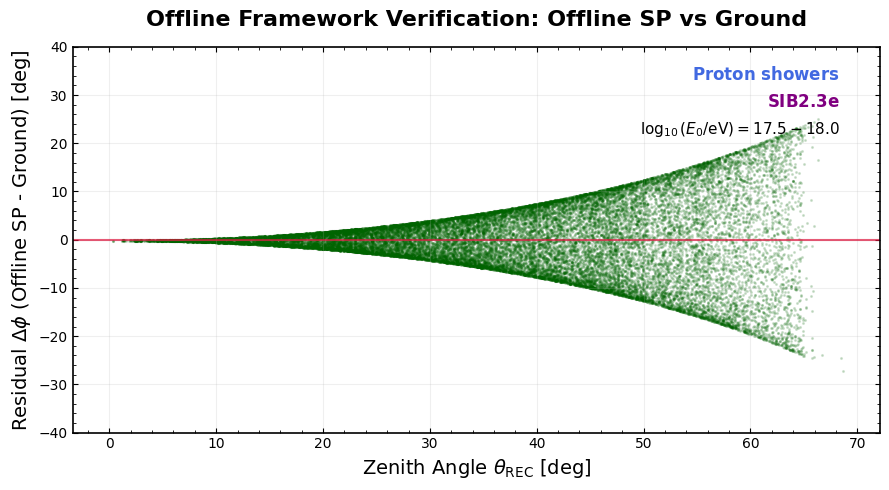

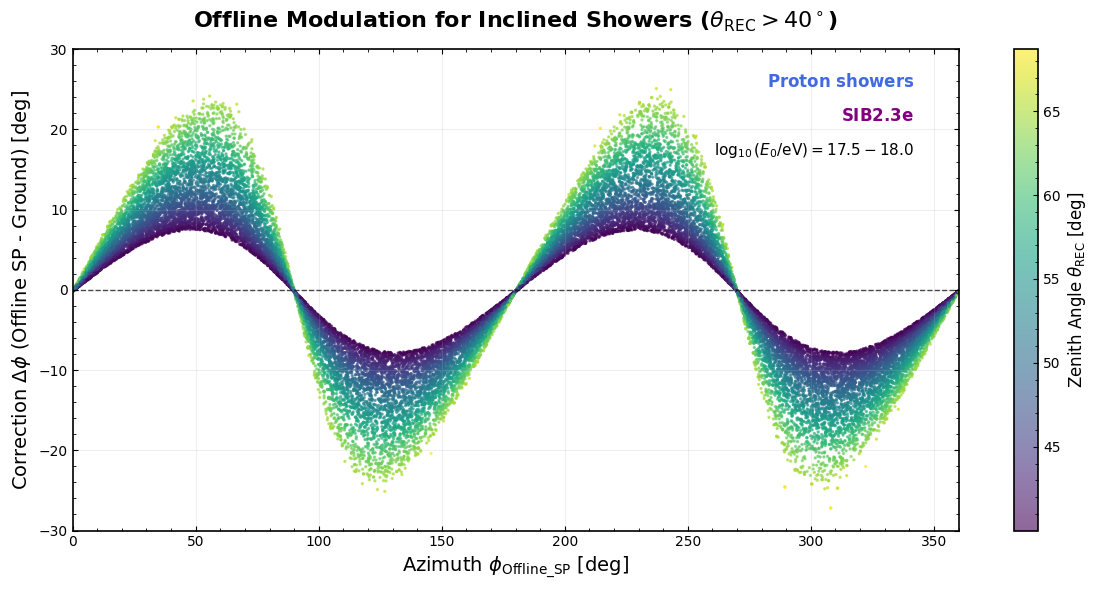

In [3]:
if len(df_infill) > 0:
    print("Desplegando la prueba: GetAzimuthSP Oficial vs Ground 2D...")
    
    # Extraemos variables
    vals_sp = ensure_degrees(df_infill['phi_plane_sp'])
    vals_ground = ensure_degrees(df_infill['phi_plane_ground'])
    vals_rec_phi = ensure_degrees(df_infill['phi_REC'])
    vals_theta_rec = ensure_degrees(df_infill['theta_REC'])

    # 1. Recuperamos el Offline SP absoluto (deshacemos el error de extracción)
    vals_sp_fixed = (vals_sp + vals_rec_phi) % 360
    
    # 2. Resta de la verdad: Offline SP vs Piso
    diff_sp_ground = ang_diff(vals_sp_fixed, vals_ground)

    # Setup de ploteo
    n_sample = min(30000, len(df_infill))
    idx = np.random.choice(df_infill.index, n_sample, replace=False)
    mask_inclined = vals_theta_rec > 40
    idx_snake = np.random.choice(df_infill[mask_inclined].index, 
                                 min(30000, mask_inclined.sum()), replace=False)

    # --- PLOT 1: TROMPETA (OFFLINE SP vs GROUND) ---
    fig1, ax1 = plt.subplots(figsize=(9, 5))
    ax1.scatter(vals_theta_rec.loc[idx], diff_sp_ground.loc[idx], 
                s=1.5, c='darkgreen', alpha=0.15, rasterized=True)
    ax1.axhline(0, color='crimson', linestyle='-', lw=1.5, alpha=0.7)
    
    ax1.set_title(r"Offline Framework Verification: Offline SP vs Ground", fontsize=16, fontweight='bold', pad=15)
    ax1.set_xlabel(r"Zenith Angle $\theta_{\mathrm{REC}}$ [deg]", fontsize=14)
    ax1.set_ylabel(r"Residual $\Delta\phi$ (Offline SP - Ground) [deg]", fontsize=14)
    ax1.set_ylim(-40, 40)
    add_physics_annotations(ax1) 
    ax1.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    # --- PLOT 2: SERPIENTE (OFFLINE SP vs GROUND para inclinadas) ---
    if mask_inclined.sum() > 100:
        fig2, ax2 = plt.subplots(figsize=(12, 6))
        sc = ax2.scatter(vals_sp_fixed.loc[idx_snake], 
                         diff_sp_ground.loc[idx_snake], 
                         c=vals_theta_rec.loc[idx_snake], 
                         cmap='viridis', s=2, alpha=0.6, rasterized=True)
        ax2.axhline(0, color='black', linestyle='--', lw=1, alpha=0.7)
        ax2.set_title(r"Offline Modulation for Inclined Showers ($\theta_{\mathrm{REC}} > 40^\circ$)", 
                     fontsize=16, fontweight='bold', pad=15)
        ax2.set_xlabel(r"Azimuth $\phi_{\mathrm{Offline\_SP}}$ [deg]", fontsize=14)
        ax2.set_ylabel(r"Correction $\Delta\phi$ (Offline SP - Ground) [deg]", fontsize=14)
        
        cbar = plt.colorbar(sc, ax=ax2)
        cbar.set_label(r"Zenith Angle $\theta_{\mathrm{REC}}$ [deg]", fontsize=12)
        add_physics_annotations(ax2) 
        ax2.set_xlim(0, 360)
        ax2.set_ylim(-30, 30)
        ax2.grid(True, alpha=0.2)
        plt.tight_layout()
        plt.show()

Desplegando la prueba UMD: Darko 3D vs Ground 2D (734139 módulos)...


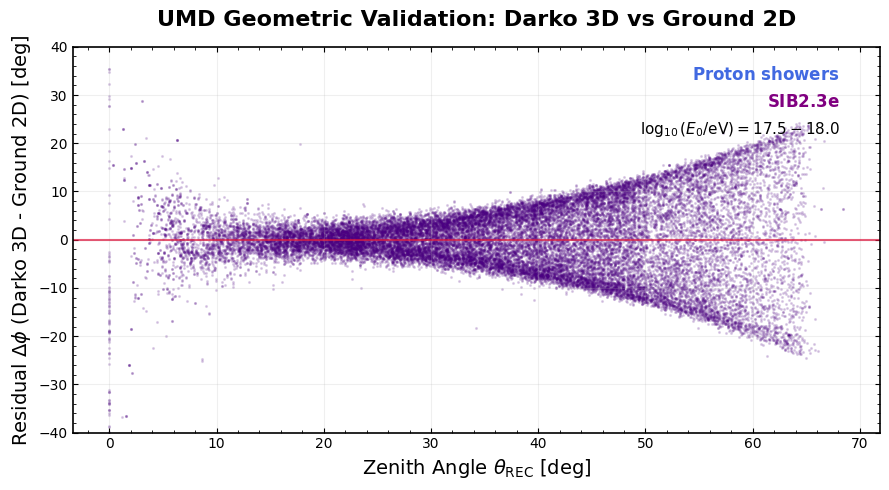

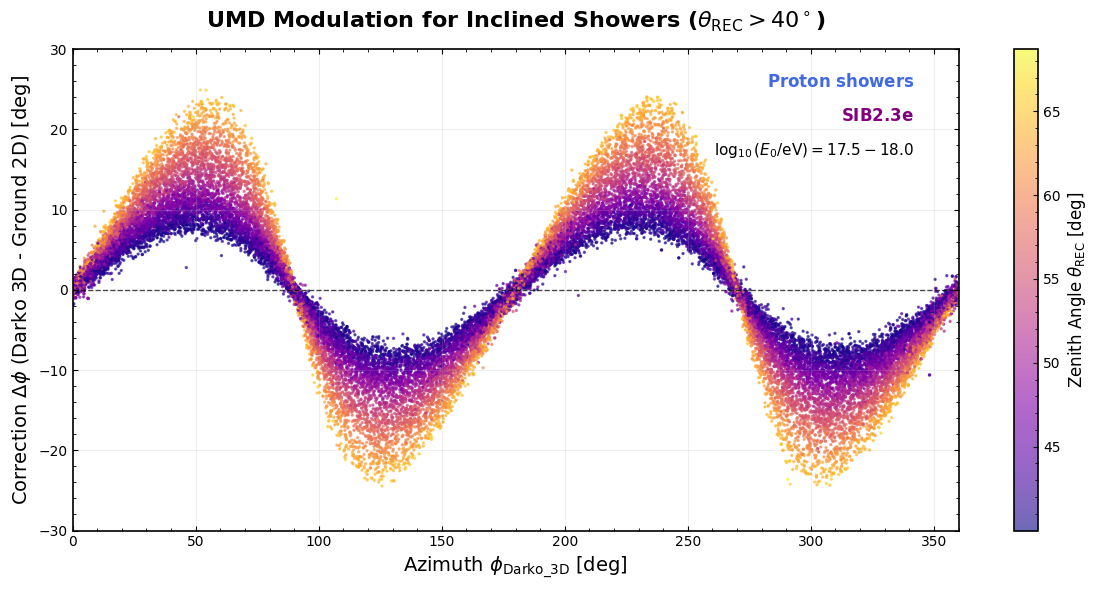

In [4]:
# =========================================================================
# CELDA: VALIDACIÓN DEFINITIVA DEL UMD (DARKO 3D VS GROUND 2D)
# =========================================================================

# --- Filtramos solo los eventos donde el UMD tiene posición física real ---
df_umd = df_infill[df_infill['is_true_umd_pos'] == True].copy()

if len(df_umd) > 0:
    print(f"Desplegando la prueba UMD: Darko 3D vs Ground 2D ({len(df_umd)} módulos)...")
    
    # Extraemos variables
    vals_darko = ensure_degrees(df_umd['phi_plane_darko_rec'])
    vals_ground = ensure_degrees(df_umd['phi_plane_ground'])
    vals_theta_rec = ensure_degrees(df_umd['theta_REC'])

    # ❗️ Resta directa: Darko (3D) vs Piso (2D) ❗️
    # No hay offset de 180 grados en la fórmula de Darko, así que van directo
    diff_darko_ground = ang_diff(vals_darko, vals_ground)

    # Setup de ploteo
    n_sample = min(30000, len(df_umd))
    idx = np.random.choice(df_umd.index, n_sample, replace=False)
    mask_inclined = vals_theta_rec > 40
    idx_snake = np.random.choice(df_umd[mask_inclined].index, 
                                 min(30000, mask_inclined.sum()), replace=False)

    # --- PLOT 1: TROMPETA (DARKO 3D vs GROUND) ---
    fig1, ax1 = plt.subplots(figsize=(9, 5))
    ax1.scatter(vals_theta_rec.loc[idx], diff_darko_ground.loc[idx], 
                s=1.5, c='indigo', alpha=0.15, rasterized=True)
    ax1.axhline(0, color='crimson', linestyle='-', lw=1.5, alpha=0.7)
    
    ax1.set_title(r"UMD Geometric Validation: Darko 3D vs Ground 2D", fontsize=16, fontweight='bold', pad=15)
    ax1.set_xlabel(r"Zenith Angle $\theta_{\mathrm{REC}}$ [deg]", fontsize=14)
    ax1.set_ylabel(r"Residual $\Delta\phi$ (Darko 3D - Ground 2D) [deg]", fontsize=14)
    ax1.set_ylim(-40, 40)
    add_physics_annotations(ax1) 
    ax1.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    # --- PLOT 2: SERPIENTE (DARKO 3D vs GROUND para inclinadas) ---
    if mask_inclined.sum() > 100:
        fig2, ax2 = plt.subplots(figsize=(12, 6))
        sc = ax2.scatter(vals_darko.loc[idx_snake], 
                         diff_darko_ground.loc[idx_snake], 
                         c=vals_theta_rec.loc[idx_snake], 
                         cmap='plasma', s=2, alpha=0.6, rasterized=True)
        ax2.axhline(0, color='black', linestyle='--', lw=1, alpha=0.7)
        ax2.set_title(r"UMD Modulation for Inclined Showers ($\theta_{\mathrm{REC}} > 40^\circ$)", 
                     fontsize=16, fontweight='bold', pad=15)
        ax2.set_xlabel(r"Azimuth $\phi_{\mathrm{Darko\_3D}}$ [deg]", fontsize=14)
        ax2.set_ylabel(r"Correction $\Delta\phi$ (Darko 3D - Ground 2D) [deg]", fontsize=14)
        
        cbar = plt.colorbar(sc, ax=ax2)
        cbar.set_label(r"Zenith Angle $\theta_{\mathrm{REC}}$ [deg]", fontsize=12)
        add_physics_annotations(ax2) 
        ax2.set_xlim(0, 360)
        ax2.set_ylim(-30, 30)
        ax2.grid(True, alpha=0.2)
        plt.tight_layout()
        plt.show()
else:
    print("No hay posiciones válidas de UMD en este dataset.")

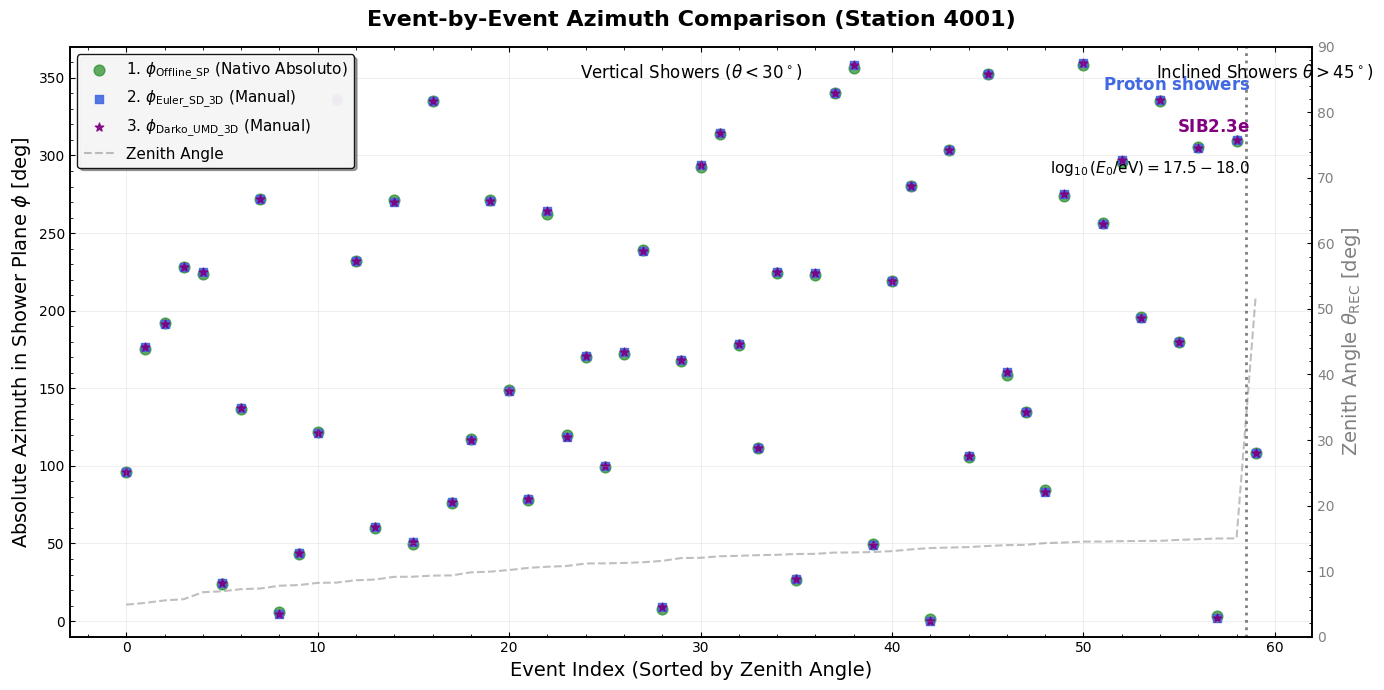

In [5]:
# =========================================================================
# CELDA: COMPARACIÓN DIRECTA DE AZIMUTH (EVENTO POR EVENTO) - CORREGIDO
# =========================================================================

# --- 1. SELECCIÓN Y LIMPIEZA ---
df_valid = df_infill[df_infill['is_true_umd_pos'] == True].copy()

if len(df_valid) > 0:
    top_station = df_valid['sdId'].value_counts().index[0]
    df_single = df_valid[df_valid['sdId'] == top_station].drop_duplicates(subset=['event_id']).copy()

    # Eliminamos el ruido de la singularidad: nos quedamos con eventos donde la rec fue casi perfecta
    diff_rec_mc = ang_diff(ensure_degrees(df_single['phi_REC']), ensure_degrees(df_single['phi_MC']))
    df_clean = df_single[np.abs(diff_rec_mc) < 1.5].copy()

    if len(df_clean) > 60:
        df_low = df_clean[ensure_degrees(df_clean['theta_REC']) < 15].sample(59, random_state=42)
        df_high = df_clean[ensure_degrees(df_clean['theta_REC']) > 45].sample(1, random_state=42)
        df_plot = pd.concat([df_low, df_high]).sort_values('theta_REC').reset_index(drop=True)
    else:
        df_plot = df_clean.sort_values('theta_REC').reset_index(drop=True)

    # --- 2. ❗️ CORRECCIÓN: ALINEACIÓN DE VARIABLES ABSOLUTAS ❗️ ---
    sp_raw = ensure_degrees(df_plot['phi_plane_sp'])
    phi_rec = ensure_degrees(df_plot['phi_REC'])
    
    # 1. SP Nativo Absoluto (restaurado)
    sp_aligned = (sp_raw + phi_rec) % 360
    
    # 2. Euler Absoluto
    euler_aligned = (ensure_degrees(df_plot['phi_plane_euler_MC']) - 180) % 360
    
    # 3. Darko Absoluto
    darko_aligned = ensure_degrees(df_plot['phi_plane_darko_rec'])
    
    zenith = ensure_degrees(df_plot['theta_REC'])

    # --- 3. PLOTEO ESTILO "TRACKING" ---
    fig, ax1 = plt.subplots(figsize=(14, 7))
    x_indices = np.arange(len(df_plot))
    
    ax1.scatter(x_indices, sp_aligned, color='forestgreen', s=60, marker='o', alpha=0.7, label=r'1. $\phi_{\mathrm{Offline\_SP}}$ (Nativo Absoluto)')
    ax1.scatter(x_indices, euler_aligned, color='royalblue', s=40, marker='s', alpha=0.9, label=r'2. $\phi_{\mathrm{Euler\_SD\_3D}}$ (Manual)')
    ax1.scatter(x_indices, darko_aligned, color='purple', s=40, marker='*', alpha=0.9, label=r'3. $\phi_{\mathrm{Darko\_UMD\_3D}}$ (Manual)')

    ax1.set_title(f"Event-by-Event Azimuth Comparison (Station {top_station})", fontsize=16, fontweight='bold', pad=15)
    ax1.set_xlabel("Event Index (Sorted by Zenith Angle)", fontsize=14)
    ax1.set_ylabel(r"Absolute Azimuth in Shower Plane $\phi$ [deg]", fontsize=14)
    ax1.set_ylim(-10, 370)
    
    ax2 = ax1.twinx()
    ax2.plot(x_indices, zenith, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, label='Zenith Angle')
    ax2.set_ylabel(r"Zenith Angle $\theta_{\mathrm{REC}}$ [deg]", color='gray', fontsize=14)
    ax2.set_ylim(0, 90)
    ax2.tick_params(axis='y', labelcolor='gray')

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11, framealpha=0.9)
    
    add_physics_annotations(ax1)
    
    ax1.axvline(x=len(df_low)-0.5, color='black', linestyle=':', alpha=0.5)
    ax1.text(len(df_low)/2, 350, r'Vertical Showers ($\theta < 30^\circ$)', ha='center', fontsize=12, color='black')
    ax1.text(len(df_low) + len(df_high)/2, 350, r'Inclined Showers $\theta > 45^\circ$)', ha='center', fontsize=12, color='black')

    ax1.grid(True, alpha=0.2)
    plt.tight_layout()
    #plt.savefig('Direct_Comparison_50_Events_Corrected.jpg', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Faltan datos.")

MC Closure Test: Procesando 215304 módulos inclinados...


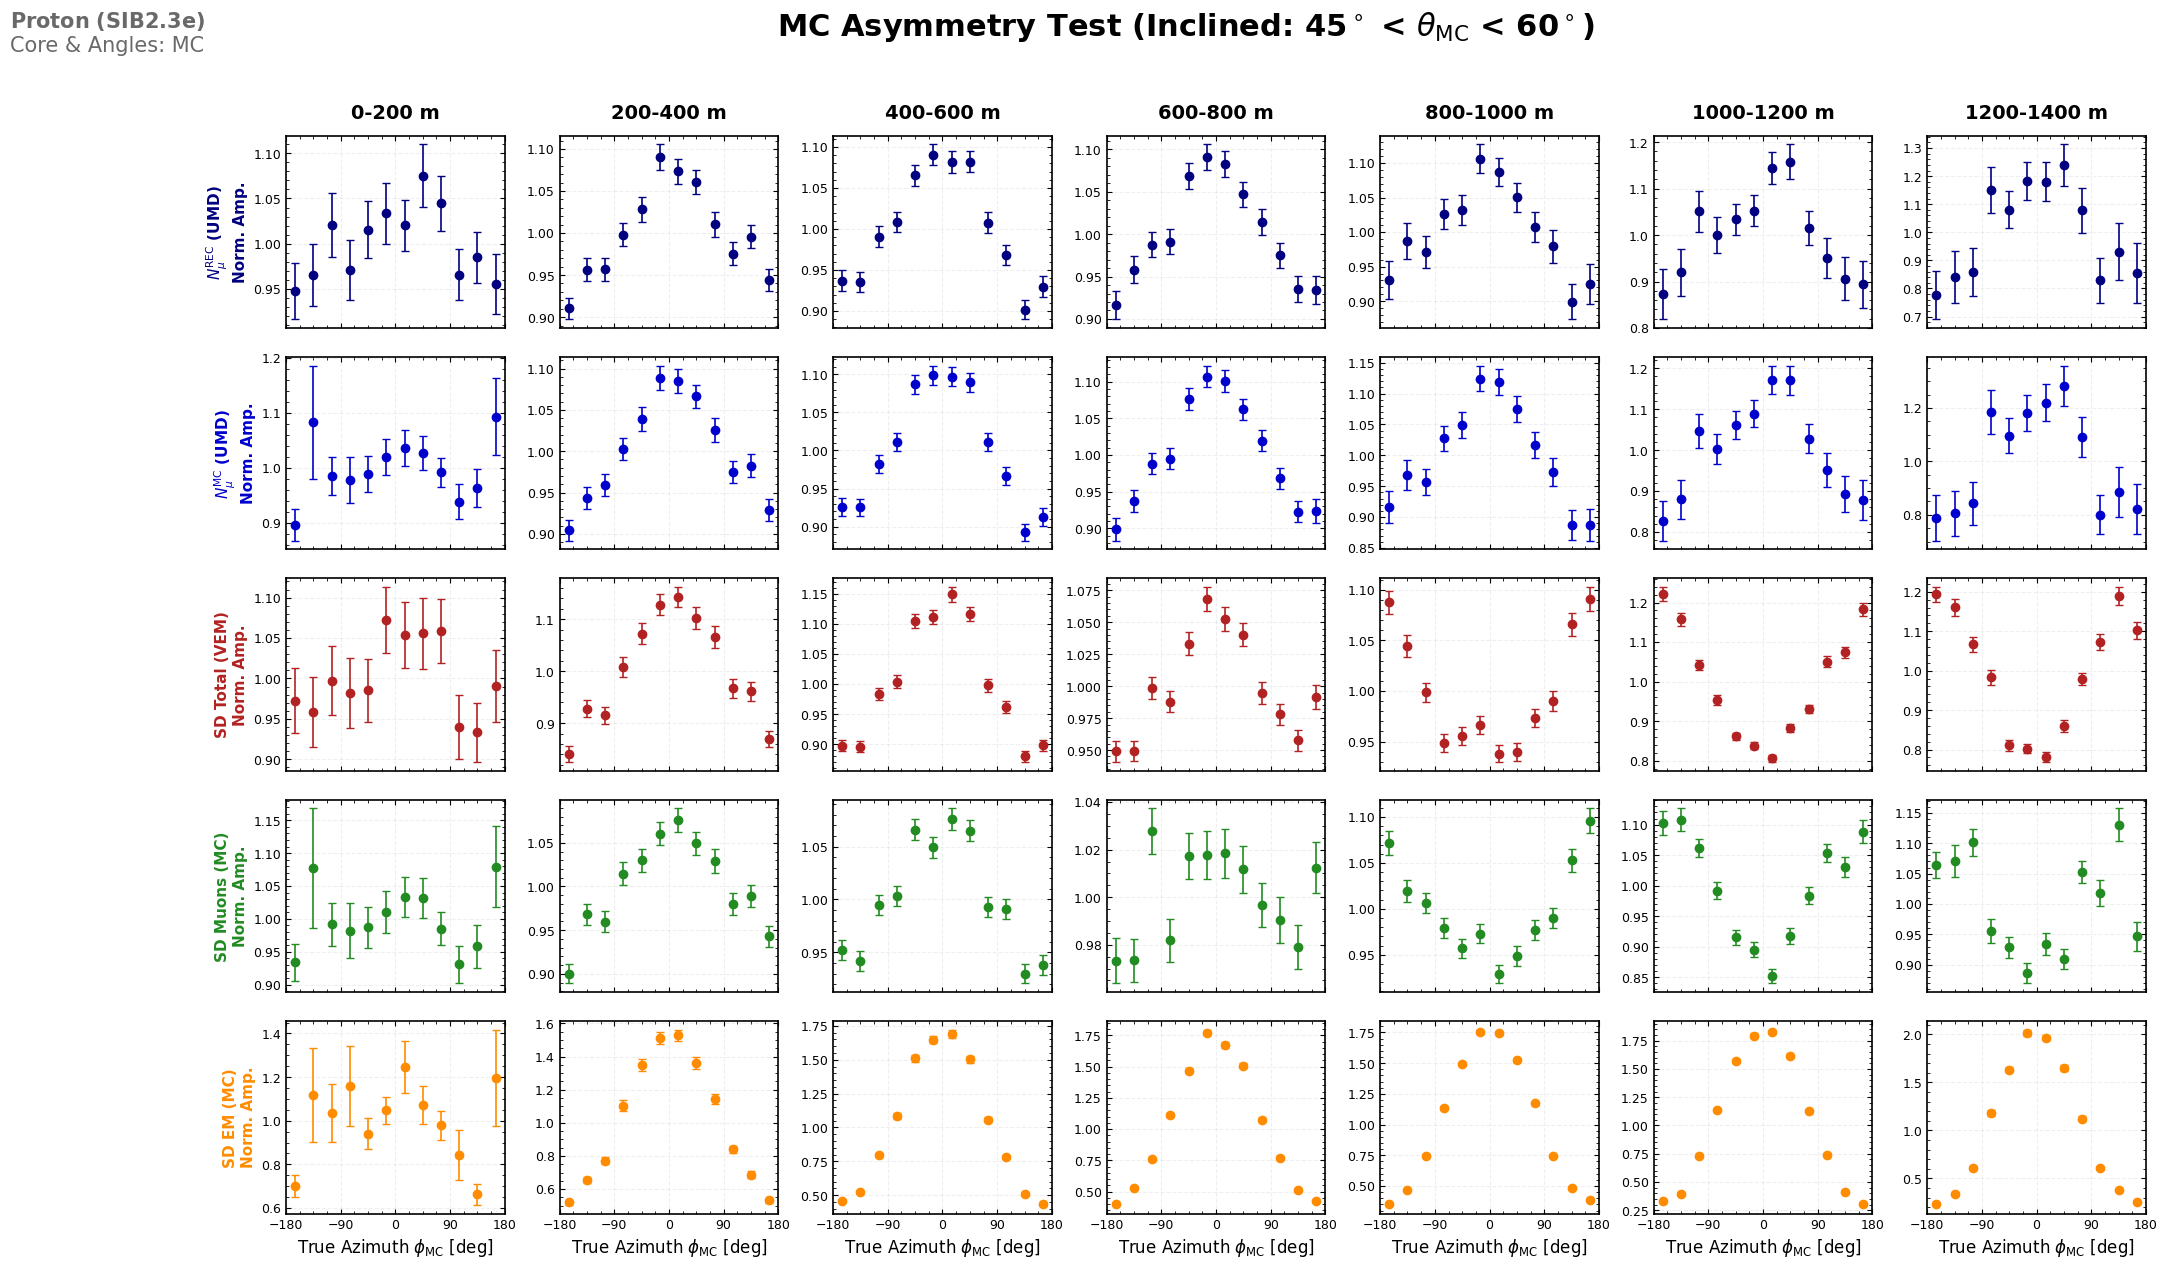

In [6]:
# =========================================================================
# CELDA: MC CLOSURE TEST (ASIMETRÍA AZIMUTAL PURA) - 5 FILAS x 7 COLUMNAS
# =========================================================================

# 1. Filtro de Eventos (45°-60° para maximizar efecto físico)
df_inf = df_infill[(df_infill['counterId'] >= 100000) & 
                   (df_infill['theta_MC'] >= 45) & 
                   (df_infill['theta_MC'] < 60)].copy()

if len(df_inf) > 0:
    print(f"MC Closure Test: Procesando {len(df_inf)} módulos inclinados...")
    
    col_distancia = 'r_core_MC'
    r_edges = [0, 200, 400, 600, 800, 1000, 1200, 1400] 
    r_labels = ["0-200 m", "200-400 m", "400-600 m", "600-800 m", "800-1000 m", "1000-1200 m", "1200-1400 m"]
    df_inf['r_bin'] = pd.cut(df_inf[col_distancia], bins=r_edges, labels=False, include_lowest=True)

    phi_bin_edges = np.linspace(-180, 180, 13)
    phi_centers = 0.5 * (phi_bin_edges[1:] + phi_bin_edges[:-1])

    # --- 2. ÁNGULO PURAMENTE MC (EULER FIX) ---
    euler_mc_true = ensure_degrees(df_inf['phi_plane_euler_MC_true_core'])
    euler_abs = (euler_mc_true - 180) % 360
    df_inf['phi_MC_Truth'] = (euler_abs + 180) % 360 - 180

    # --- 3. PLOTEO (5 Filas x 7 Columnas) ---
    # ❗️ Quitamos sharey='row' para que cada plot tenga su propia escala ❗️
    fig, axs = plt.subplots(5, 7, figsize=(24, 14), sharex=True)
    plt.rcParams.update(hep_style)

    configs = [
        ('nMuones_REC', r'$N_\mu^{\mathrm{REC}}$ (UMD)', 'navy'), 
        ('nMuones_MC', r'$N_\mu^{\mathrm{MC}}$ (UMD)', 'mediumblue'),
        ('sdSignal_REC', r'SD Total (VEM)', 'firebrick'),
        ('sd_nMuons_MC', r'SD Muons (MC)', 'forestgreen'),
        ('sd_nEM_MC', r'SD EM (MC)', 'darkorange')
    ]

    for k, (col_name, label, color) in enumerate(configs):
        for j in range(7):
            ax = axs[k, j]
            df_r = df_inf[df_inf['r_bin'] == j].copy()
            
            if df_r.empty or len(df_r.dropna(subset=[col_name, 'phi_MC_Truth'])) < 15:
                ax.text(0.5, 0.5, "Low Stats", ha='center', alpha=0.5, transform=ax.transAxes)
                continue

            df_r['bin_phi'] = pd.cut(df_r['phi_MC_Truth'], bins=phi_bin_edges)
            st = df_r.groupby('bin_phi', observed=True)[col_name].agg(['mean','sem']).dropna()
            
            if st.empty: continue

            means = st['mean']
            sems = st['sem']
            norm = means.mean()
            if norm == 0: continue
            
            ax.errorbar(phi_centers, means/norm, yerr=sems/norm, fmt='o', 
                        color=color, markersize=6, capsize=3, elinewidth=1.2)
            
            # Estética de sub-panel
            ax.grid(True, alpha=0.2, linestyle='--')
            ax.set_xlim(-180, 180)
            ax.set_xticks([-180, -90, 0, 90, 180])
            
            # ❗️ Ajuste fino de ticks para que no se pisen con los de arriba ❗️
            ax.tick_params(axis='both', which='major', labelsize=9)

            if k == 0: 
                ax.set_title(r_labels[j], fontsize=14, fontweight='bold', pad=12)
            
            if k == 4: 
                ax.set_xlabel(r"True Azimuth $\phi_{\mathrm{MC}}$ [deg]", fontsize=12)
            
            if j == 0: 
                # ❗️ Aplicamos el color al label del eje Y ❗️
                ax.set_ylabel(f"{label}\nNorm. Amp.", fontsize=11, fontweight='bold', color=color)

    fig.suptitle(r"MC Asymmetry Test (Inclined: 45$^\circ$ < $\theta_{\mathrm{MC}}$ < 60$^\circ$)", 
                 fontsize=22, fontweight='bold', y=0.97)
    
    # Anotación física global
    fig.text(0.01, 0.97, r"$\mathbf{Proton\ (SIB2.3e)}$" + "\n" + r"Core & Angles: MC", fontsize=15, va='top', ha='left', color='dimgray')

    plt.subplots_adjust(hspace=0.15, wspace=0.25) # Un poco más de espacio para que los labels no se encimen
    # plt.savefig('MC_Closure_Full_Grid.jpg', dpi=300, bbox_inches='tight')
    plt.show()

else:
    print("No hay suficientes datos en el rango zenital de 45-60 grados.")

Analizando Reconstrucción: 215304 módulos en rango 45-60 REC...


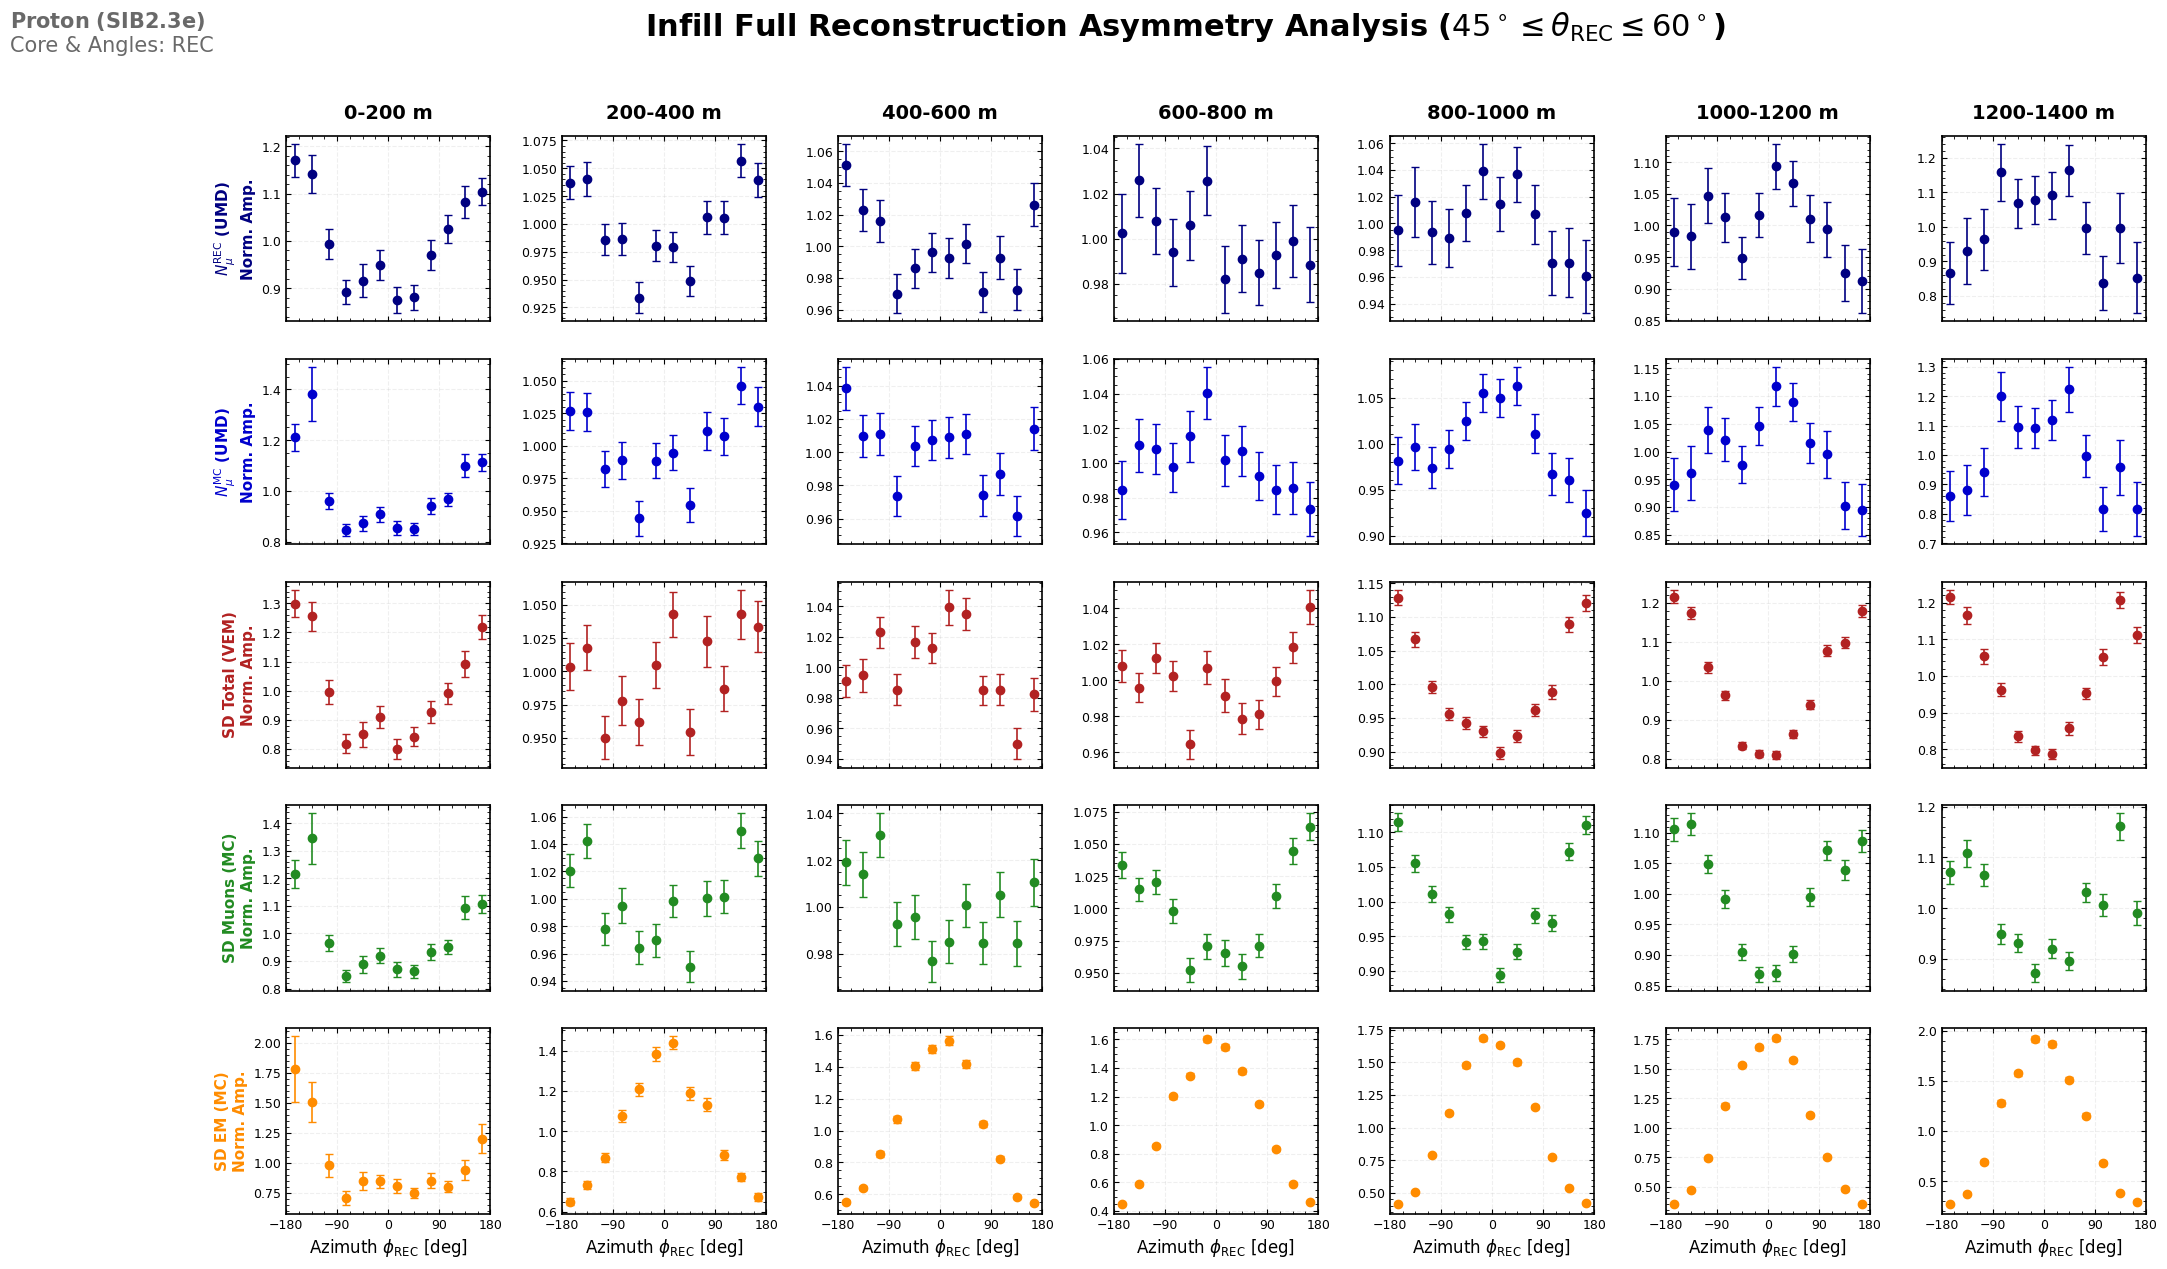

In [7]:
# =========================================================================
# CELDA: FULL RECONSTRUCTION ANALYSIS (REC VS MC - 5x7 GRID)
# =========================================================================

if len(df_inf) > 0:
    print(f"Analizando Reconstrucción: {len(df_inf)} módulos en rango 45-60 REC...")
    
    # --- VARIABLES REC (EL MUNDO SEGÚN EL DETECTOR) ---
    col_distancia = 'r_core' # Distancia Reconstruida
    r_edges = [0, 200, 400, 600, 800, 1000, 1200, 1400] 
    r_labels = ["0-200 m", "200-400 m", "400-600 m", "600-800 m", "800-1000 m", "1000-1200 m", "1200-1400 m"]
    df_inf['r_bin'] = pd.cut(df_inf[col_distancia], bins=r_edges, labels=False, include_lowest=True)

    # --- ÁNGULOS EN EL PLANO REC (ARREGLANDO EL BUG DEL SP NATIVO) ---
    sp_raw = ensure_degrees(df_inf['phi_plane_sp'])
    phi_rec = ensure_degrees(df_inf['phi_REC'])
    
    # ❗️ Recuperamos el ángulo absoluto sumando la dirección de la lluvia ❗️
    p_rec_absoluto = (sp_raw + phi_rec) % 360
    
    # Lo centramos entre -180 y 180
    df_inf['p_rec_cen'] = (p_rec_absoluto + 180) % 360 - 180
    df_inf['p_mc_cen'] = df_inf['p_rec_cen'] # Forzamos a que el MC use la geometría REC

    phi_bin_edges = np.linspace(-180, 180, 13)
    phi_centers = 0.5 * (phi_bin_edges[1:] + phi_bin_edges[:-1])

    # --- 2. CONFIGURACIÓN DE LAS 5 FILAS ---
    configs = [
        ('nMuones_REC', r'$N_\mu^{\mathrm{REC}}$ (UMD)', 'navy'), 
        ('nMuones_MC', r'$N_\mu^{\mathrm{MC}}$ (UMD)', 'mediumblue'),
        ('sdSignal_REC', r'SD Total (VEM)', 'firebrick'),
        ('sd_nMuons_MC', r'SD Muons (MC)', 'forestgreen'),
        ('sd_nEM_MC', r'SD EM (MC)', 'darkorange')
    ]

    # --- 3. PLOTEO (5 Filas x 7 Columnas) ---
    # Importante: sharey=False para que cada bin radial luzca su asimetría
    fig, axs = plt.subplots(5, 7, figsize=(24, 14), sharex=True)
    plt.rcParams.update(hep_style)

    for k, (col_name, label, color) in enumerate(configs):
        for j in range(7):
            ax = axs[k, j]
            df_r = df_inf[df_inf['r_bin'] == j].copy()
            
            # Filtro de estadística mínima para no plotear ruido puro
            if df_r.empty or len(df_r.dropna(subset=[col_name])) < 15:
                ax.text(0.5, 0.5, "Baja Est.", ha='center', alpha=0.5, transform=ax.transAxes)
                continue

            # Determinamos la columna de ángulo según tu lógica
            angle_col = 'p_rec_cen' if 'REC' in col_name else 'p_mc_cen'
            df_r['bin_phi'] = pd.cut(df_r[angle_col], bins=phi_bin_edges)
            
            # Agrupamos. Usamos observed=False para que st siempre tenga 12 filas (12 bines)
            # Esto evita el ValueError al plotear contra phi_centers
            st = df_r.groupby('bin_phi', observed=False)[col_name].agg(['mean','sem'])
            
            means = st['mean']
            sems = st['sem']
            norm = means.mean()
            
            if norm == 0 or np.isnan(norm): continue
            
            # Ploteamos con el color de la configuración
            ax.errorbar(phi_centers, means/norm, yerr=sems/norm, fmt='o', 
                        color=color, markersize=6, capsize=3, elinewidth=1.2)
            
            # Estética de cada panel
            ax.grid(True, alpha=0.2, linestyle='--')
            ax.set_xlim(-180, 180)
            ax.set_xticks([-180, -90, 0, 90, 180])
            ax.tick_params(axis='both', labelsize=9)

            if k == 0: 
                ax.set_title(r_labels[j], fontsize=14, fontweight='bold', pad=12)
            
            if k == 4: 
                ax.set_xlabel(r"Azimuth $\phi_{\mathrm{REC}}$ [deg]", fontsize=12)
            
            if j == 0: 
                # Matchamos el color del texto con el de los puntos
                ax.set_ylabel(f"{label}\nNorm. Amp.", fontsize=11, fontweight='bold', color=color)

    fig.suptitle(r"Infill Full Reconstruction Asymmetry Analysis ($45^\circ \leq \theta_{\mathrm{REC}} \leq 60^\circ$)", 
                 fontsize=22, fontweight='bold', y=0.97)
    
    # Anotación física global
    fig.text(0.01, 0.97, r"$\mathbf{Proton\ (SIB2.3e)}$" + "\n" + r"Core & Angles: REC", fontsize=15, va='top', ha='left', color='dimgray')


    plt.subplots_adjust(hspace=0.2, wspace=0.35)
    plt.show()
else:
    print("No hay datos reconstruidos en ese rango.")

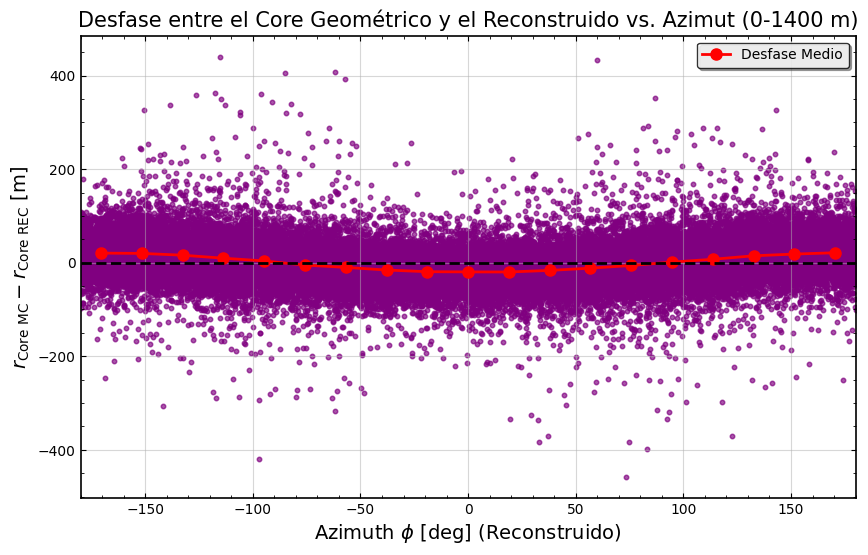

In [12]:
# =========================================================================
# CELDA: CHEQUEO DE DESFASE CORE REC vs CORE MC (CORREGIDA)
# =========================================================================

# Elegimos un bin de distancia lejano donde vemos el problema (ej. 800-1000m)
df_far = df_inf[(df_inf['r_core'] > 0) & (df_inf['r_core'] < 1400)].copy()

# Calculamos la diferencia de distancia: ¿Cuánto le erró el Offline?
df_far['delta_r'] = df_far['r_core_MC'] - df_far['r_core']

# Aseguramos que el ángulo reconstruido esté en grados y centrado [-180, 180]
df_far['phi_deg'] = (np.rad2deg(df_far['phi_plane_euler_MC_true_core']) if df_far['phi_plane_euler_MC_true_core'].abs().max() < 7 else df_far['phi_plane_euler_MC_true_core'])
df_far['phi_deg'] = (df_far['phi_deg'] + 180) % 360 - 180

fig, ax = plt.subplots(figsize=(10, 6))

# Ploteamos el scatter de fondo
ax.scatter(df_far['phi_deg'], df_far['delta_r'], alpha=0.3, color='purple', s=10)

# Calculamos la media por bin angular (¡EN GRADOS!)
bins = np.linspace(-180, 180, 20)
bin_centers = (bins[:-1] + bins[1:]) / 2

df_far['phi_bin'] = pd.cut(df_far['phi_deg'], bins)

# observed=False evita que se rompan las dimensiones si un bin está vacío
mean_delta_r = df_far.groupby('phi_bin', observed=False)['delta_r'].mean()

ax.plot(bin_centers, mean_delta_r.values, 'ro-', lw=2, markersize=8, label='Desfase Medio')

ax.set_xlabel(r"Azimuth $\phi$ [deg] (Reconstruido)", fontsize=14)
ax.set_ylabel(r"$r_{\mathrm{Core\ MC}} - r_{\mathrm{Core\ REC}}$ [m]", fontsize=14)
ax.set_title("Desfase entre el Core Geométrico y el Reconstruido vs. Azimut (0-1400 m)", fontsize=15)
ax.axhline(0, color='k', linestyle='--', lw=2)
ax.set_xlim(-180, 180)
ax.grid(True, alpha=0.5)
ax.legend()

plt.show()